# Statistics

A chart shows a shape; a statistic names it. The [datachart.utils.stats](../../../references/utils/stats/) module holds the numbers behind the charts (means, quantiles, correlations, fits, densities, smoothers) as plain functions on plain lists, so the same values that go into a chart can go into its title, its error bars, or a second series laid over it. This guide shows what each function answers and how its result feeds back into a chart, starting with the basics and building up to worked examples on real data.

Looking for a specific statistic? Jump straight to the [quick reference](#the-functions), which maps common questions to the function that answers them.

In [1]:
from datachart.utils import stats

## Basics

The examples in this guide share one dataset: the flipper length (in mm) and body mass (in g) of the 342 penguins measured on three islands of the Palmer Archipelago, Antarctica (source: the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset, Gorman, Williams and Fraser 2014, released under CC0). The data lives in a hidden cell: `flipper` and `mass` are the pooled values, and `flipper_by_species` and `mass_by_species` split them by species (Adelie, Chinstrap and Gentoo, in the order of `SPECIES`). Every function below takes such a list of numbers, and most take nothing else:

In [2]:
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]

# Palmer penguins (Gorman et al. 2014, CC0): (flipper length in mm, body mass in g) per penguin
PENGUINS = {
    "Adelie": [
        (181, 3750), (186, 3800), (195, 3250), (193, 3450), (190, 3650), (181, 3625),
        (195, 4675), (193, 3475), (190, 4250), (186, 3300), (180, 3700), (182, 3200),
        (191, 3800), (198, 4400), (185, 3700), (195, 3450), (197, 4500), (184, 3325),
        (194, 4200), (174, 3400), (180, 3600), (189, 3800), (185, 3950), (180, 3800),
        (187, 3800), (183, 3550), (187, 3200), (172, 3150), (180, 3950), (178, 3250),
        (178, 3900), (188, 3300), (184, 3900), (195, 3325), (196, 4150), (190, 3950),
        (180, 3550), (181, 3300), (184, 4650), (182, 3150), (195, 3900), (186, 3100),
        (196, 4400), (185, 3000), (190, 4600), (182, 3425), (179, 2975), (190, 3450),
        (191, 4150), (186, 3500), (188, 4300), (190, 3450), (200, 4050), (187, 2900),
        (191, 3700), (186, 3550), (193, 3800), (181, 2850), (194, 3750), (185, 3150),
        (195, 4400), (185, 3600), (192, 4050), (184, 2850), (192, 3950), (195, 3350),
        (188, 4100), (190, 3050), (198, 4450), (190, 3600), (190, 3900), (196, 3550),
        (197, 4150), (190, 3700), (195, 4250), (191, 3700), (184, 3900), (187, 3550),
        (195, 4000), (189, 3200), (196, 4700), (187, 3800), (193, 4200), (191, 3350),
        (194, 3550), (190, 3800), (189, 3500), (189, 3950), (190, 3600), (202, 3550),
        (205, 4300), (185, 3400), (186, 4450), (187, 3300), (208, 4300), (190, 3700),
        (196, 4350), (178, 2900), (192, 4100), (192, 3725), (203, 4725), (183, 3075),
        (190, 4250), (193, 2925), (184, 3550), (199, 3750), (190, 3900), (181, 3175),
        (197, 4775), (198, 3825), (191, 4600), (193, 3200), (197, 4275), (191, 3900),
        (196, 4075), (188, 2900), (199, 3775), (189, 3350), (189, 3325), (187, 3150),
        (198, 3500), (176, 3450), (202, 3875), (186, 3050), (199, 4000), (191, 3275),
        (195, 4300), (191, 3050), (210, 4000), (190, 3325), (197, 3500), (193, 3500),
        (199, 4475), (187, 3425), (190, 3900), (191, 3175), (200, 3975), (185, 3400),
        (193, 4250), (193, 3400), (187, 3475), (188, 3050), (190, 3725), (192, 3000),
        (185, 3650), (190, 4250), (184, 3475), (195, 3450), (193, 3750), (187, 3700),
        (201, 4000),
    ],
    "Chinstrap": [
        (192, 3500), (196, 3900), (193, 3650), (188, 3525), (197, 3725), (198, 3950),
        (178, 3250), (197, 3750), (195, 4150), (198, 3700), (193, 3800), (194, 3775),
        (185, 3700), (201, 4050), (190, 3575), (201, 4050), (197, 3300), (181, 3700),
        (190, 3450), (195, 4400), (181, 3600), (191, 3400), (187, 2900), (193, 3800),
        (195, 3300), (197, 4150), (200, 3400), (200, 3800), (191, 3700), (205, 4550),
        (187, 3200), (201, 4300), (187, 3350), (203, 4100), (195, 3600), (199, 3900),
        (195, 3850), (210, 4800), (192, 2700), (205, 4500), (210, 3950), (187, 3650),
        (196, 3550), (196, 3500), (196, 3675), (201, 4450), (190, 3400), (212, 4300),
        (187, 3250), (198, 3675), (199, 3325), (201, 3950), (193, 3600), (203, 4050),
        (187, 3350), (197, 3450), (191, 3250), (203, 4050), (202, 3800), (194, 3525),
        (206, 3950), (189, 3650), (195, 3650), (207, 4000), (202, 3400), (193, 3775),
        (210, 4100), (198, 3775),
    ],
    "Gentoo": [
        (211, 4500), (230, 5700), (210, 4450), (218, 5700), (215, 5400), (210, 4550),
        (211, 4800), (219, 5200), (209, 4400), (215, 5150), (214, 4650), (216, 5550),
        (214, 4650), (213, 5850), (210, 4200), (217, 5850), (210, 4150), (221, 6300),
        (209, 4800), (222, 5350), (218, 5700), (215, 5000), (213, 4400), (215, 5050),
        (215, 5000), (215, 5100), (216, 4100), (215, 5650), (210, 4600), (220, 5550),
        (222, 5250), (209, 4700), (207, 5050), (230, 6050), (220, 5150), (220, 5400),
        (213, 4950), (219, 5250), (208, 4350), (208, 5350), (208, 3950), (225, 5700),
        (210, 4300), (216, 4750), (222, 5550), (217, 4900), (210, 4200), (225, 5400),
        (213, 5100), (215, 5300), (210, 4850), (220, 5300), (210, 4400), (225, 5000),
        (217, 4900), (220, 5050), (208, 4300), (220, 5000), (208, 4450), (224, 5550),
        (208, 4200), (221, 5300), (214, 4400), (231, 5650), (219, 4700), (230, 5700),
        (214, 4650), (229, 5800), (220, 4700), (223, 5550), (216, 4750), (221, 5000),
        (221, 5100), (217, 5200), (216, 4700), (230, 5800), (209, 4600), (220, 6000),
        (215, 4750), (223, 5950), (212, 4625), (221, 5450), (212, 4725), (224, 5350),
        (212, 4750), (228, 5600), (218, 4600), (218, 5300), (212, 4875), (230, 5550),
        (218, 4950), (228, 5400), (212, 4750), (224, 5650), (214, 4850), (226, 5200),
        (216, 4925), (222, 4875), (203, 4625), (225, 5250), (219, 4850), (228, 5600),
        (215, 4975), (228, 5500), (216, 4725), (215, 5500), (210, 4700), (219, 5500),
        (208, 4575), (209, 5500), (216, 5000), (229, 5950), (213, 4650), (230, 5500),
        (217, 4375), (230, 5850), (217, 4875), (222, 6000), (214, 4925), (215, 4850),
        (222, 5750), (212, 5200), (213, 5400),
    ],
}

flipper = [f for species in SPECIES for f, _ in PENGUINS[species]]
mass = [m for species in SPECIES for _, m in PENGUINS[species]]
flipper_by_species = {species: [f for f, _ in PENGUINS[species]] for species in SPECIES}
mass_by_species = {species: [m for _, m in PENGUINS[species]] for species in SPECIES}

In [3]:
flipper[:5], mass[:5]

([181, 186, 195, 193, 190], [3750, 3800, 3250, 3450, 3650])

**Basic example.** The first question about any measurement is where its values sit and how far they spread. `mean` and `stdev` answer it in the units of the data; `count` says how many values the answer rests on:

In [4]:
stats.count(flipper), stats.mean(flipper), stats.stdev(flipper)

(342, 200.91520467836258, 14.0411405685891)

The results are plain floats, so they go straight into an f-string. The most common place for one is the title of the chart it describes, which is how the rest of this guide uses them.

## The Functions

The module is organised around the questions its functions answer. The table maps each question to its function and to the section that shows it on a chart; every function is documented in the [reference](../../../references/utils/stats/).

| I want to…                                            | Use                                                   | See |
| :---------------------------------------------------- | :---------------------------------------------------- | :-- |
| know where the values sit                             | `mean`, `median`, `mode`                              | [Center](#center) |
| know how far they spread                              | `stdev`, `variance`, `quantile`, `iqr`, `minimum`, `maximum` | [Spread](#spread) |
| tell a skewed or heavy-tailed sample from a normal one | `skewness`, `kurtosis`                              | [Shape](#shape) |
| say how much two variables move together              | `correlation`, `spearman`                             | [Association](#association) |
| draw a trend line                                     | `linear_fit`                                          | [Trend line](#trend-line) |
| put an error bar on a mean                            | `bootstrap_ci`                                        | [Confidence intervals](#confidence-intervals) |
| pick the bins of a histogram from the data            | `histogram`                                           | [Binning](#binning) |
| smooth a noisy series                                 | `rolling_mean`, `ewma`, `loess`                       | [Smoothing](#smoothing) |
| draw a distribution as a curve or a contour           | `kde1d`, `kde2d`                                      | [Density estimates](#density-estimates) |

The functions accept any sequence of numbers, a list or a NumPy array, and return Python floats and lists, so their results drop into the `data` of any chart. `minimum` and `maximum` also accept dates and strings; `correlation`, `spearman`, `linear_fit`, `loess` and `kde2d` accept dates for `x`, which the [Smoothing](#smoothing) section uses.

### Center

*What is a typical value?* has three answers, and they disagree exactly when the answer matters. `mean` is the balance point and moves with every value, including outliers; `median` is the middle value and ignores them; `mode` is the most frequent value and is meant for discrete data, where values repeat. The Gentoo penguins are far heavier than the other two species, so the pooled body mass has a long right tail that pulls the mean above the median:

In [5]:
stats.mean(mass), stats.median(mass)

(4201.754385964912, 4050.0)

Flipper lengths were measured to the millimeter, so they repeat and have a mode. The three centers on a histogram show the disagreement: a [Histogram](../../charts/histogram/) of the mass with the mean and median as `vlines` puts the gap between them on the tail that causes it.

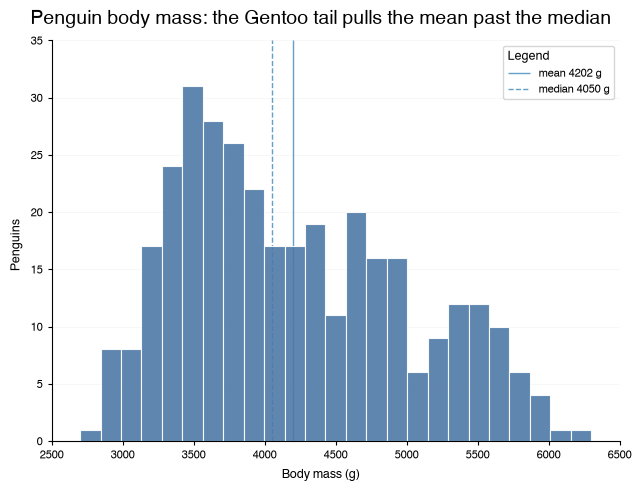

In [6]:
from datachart.charts import Histogram
from datachart.constants import FIG_SIZE, SHOW_GRID

Histogram(
    data=[{"x": m} for m in mass],
    num_bins=25,
    vlines=[
        {"x": stats.mean(mass), "label": f"mean {stats.mean(mass):.0f} g"},
        {"x": stats.median(mass), "label": f"median {stats.median(mass):.0f} g", "style": {"plot_vline_style": "--"}},
    ],
    title="Penguin body mass: the Gentoo tail pulls the mean past the median",
    xlabel="Body mass (g)",
    ylabel="Penguins",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Spread

*How different are the values from each other?* `stdev` is the typical distance from the mean, in the units of the data, and `variance` is its square (the unit a sum of independent errors adds up in). Both are pulled by outliers, so for a skewed sample the quantiles describe the spread more honestly: `quantile(values, q)` is the value below which `q` percent of the sample lies, `iqr` is the distance between the 25th and 75th quantiles (the middle half of the data), and `minimum` and `maximum` are the range. On the pooled mass:

In [7]:
{
    "stdev": round(stats.stdev(mass)),
    "variance": round(stats.variance(mass)),
    "q25": stats.quantile(mass, 25),
    "q75": stats.quantile(mass, 75),
    "iqr": stats.iqr(mass),
    "range": (stats.minimum(mass), stats.maximum(mass)),
}

{'stdev': 801,
 'variance': 641251,
 'q25': 3550.0,
 'q75': 4750.0,
 'iqr': 1200.0,
 'range': (2700.0, 6300.0)}

The five numbers a [Box Plot](../../charts/boxplot/) draws (minimum, first quartile, median, third quartile, maximum) are these same functions, and computing them by hand is how a spread gets into a table or a title. A [Dumbbell Chart](../../charts/dumbbellchart/) of the 25th and 75th quantiles per species shows where the middle half of each species sits: the Gentoo range does not even touch the other two.

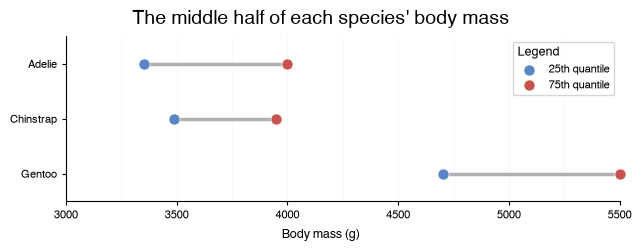

In [8]:
from datachart.charts import DumbbellChart

DumbbellChart(
    data=[
        {
            "label": species,
            "start": stats.quantile(values, 25),
            "end": stats.quantile(values, 75),
        }
        for species, values in mass_by_species.items()
    ],
    start_name="25th quantile",
    end_name="75th quantile",
    title="The middle half of each species' body mass",
    xlabel="Body mass (g)",
    show_legend=True,
    show_grid=SHOW_GRID.X,
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Shape

*Is the sample normal, or does it lean or have heavy tails?* `skewness` measures the asymmetry: positive when the tail extends to the right of the bulk, negative when it extends to the left, zero for a symmetric distribution. `kurtosis` measures the tails against a normal distribution, which scores zero: positive for heavier tails and a sharper peak, negative for lighter tails and a flatter, boxier shape. The two numbers say whether a mean and standard deviation are a fair summary (they are for a normal sample) or hide a tail. The pooled mass leans right; each species on its own is close to symmetric:

In [9]:
{
    "all": (round(stats.skewness(mass), 2), round(stats.kurtosis(mass), 2)),
    **{
        species: (round(stats.skewness(values), 2), round(stats.kurtosis(values), 2))
        for species, values in mass_by_species.items()
    },
}

{'all': (0.47, -0.73),
 'Adelie': (0.28, -0.59),
 'Chinstrap': (0.24, 0.46),
 'Gentoo': (0.07, -0.74)}

The shape statistics are easiest to read against the distribution they describe. Per-species subplots of the body mass, each titled with its skewness, show that the right lean of the pooled sample is a mixture effect, not a property of any species:

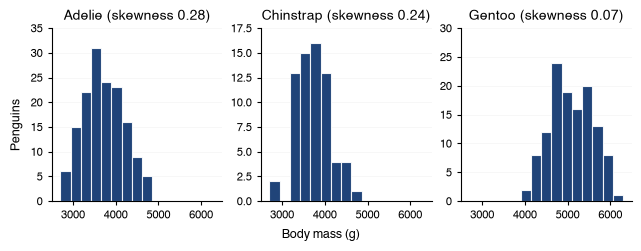

In [10]:
Histogram(
    data=[[{"x": m} for m in values] for values in mass_by_species.values()],
    subtitle=[
        f"{species} (skewness {stats.skewness(values):.2f})"
        for species, values in mass_by_species.items()
    ],
    num_bins=15,
    xlabel="Body mass (g)",
    ylabel="Penguins",
    subplots=True,
    sharex=True,
    xmin=2_500,
    xmax=6_500,
    xticks=[3_000, 4_000, 5_000, 6_000],
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Association

*When one variable goes up, does the other?* `correlation` is Pearson's coefficient: the strength of a *straight-line* relationship, from -1 through 0 (none) to 1. `spearman` is the same coefficient computed on the ranks, so it measures any relationship that only goes one way (monotone), whether or not it is a straight line, and one outlier cannot move it much. When the two agree, the relationship is linear; when Spearman is clearly larger, the relationship bends or an outlier is dragging Pearson down. Flipper length and body mass:

In [11]:
stats.correlation(flipper, mass), stats.spearman(flipper, mass)

(0.8712017673060116, 0.8399741230312999)

A correlation belongs next to the scatter it summarises. The [Scatter Chart](../../charts/scatterchart/) can print it by itself with `show_correlation`; computing it here instead lets the title carry both coefficients, and the per-species correlations show that the relationship holds *within* each species too, not only because the species differ in size:

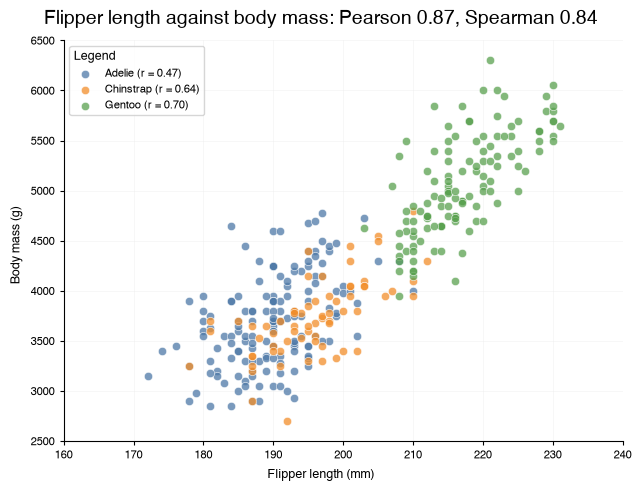

In [12]:
from datachart.charts import ScatterChart

ScatterChart(
    data=[
        [{"x": f, "y": m} for f, m in PENGUINS[species]]
        for species in SPECIES
    ],
    subtitle=[
        f"{species} (r = {stats.correlation(flipper_by_species[species], mass_by_species[species]):.2f})"
        for species in SPECIES
    ],
    title=(
        f"Flipper length against body mass: Pearson {stats.correlation(flipper, mass):.2f}, "
        f"Spearman {stats.spearman(flipper, mass):.2f}"
    ),
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Trend line

*How much does y change per unit of x?* A correlation says how tight a relationship is, not how steep. `linear_fit(x, y)` fits the straight line `y = slope * x + intercept` and returns `(slope, intercept, r2)`, where the slope is the rate in the units of the data and `r2` is the share of the variation in `y` the line explains (1 is a perfect fit). Across all penguins, each extra millimeter of flipper goes with about 50 g of body mass:

In [13]:
slope, intercept, r2 = stats.linear_fit(flipper, mass)
slope, intercept, r2

(49.68556640610008, -5780.831358077061, 0.7589925193571179)

The fit is a trend line waiting to be drawn: evaluate `slope * x + intercept` at the two ends of the x range and lay the resulting [Line Chart](../../charts/linechart/) over the scatter with a [Panel](../panel/). The `show_regression` option of the scatter chart draws the same line; computing the fit here puts the slope in the legend, where it answers the question in words.

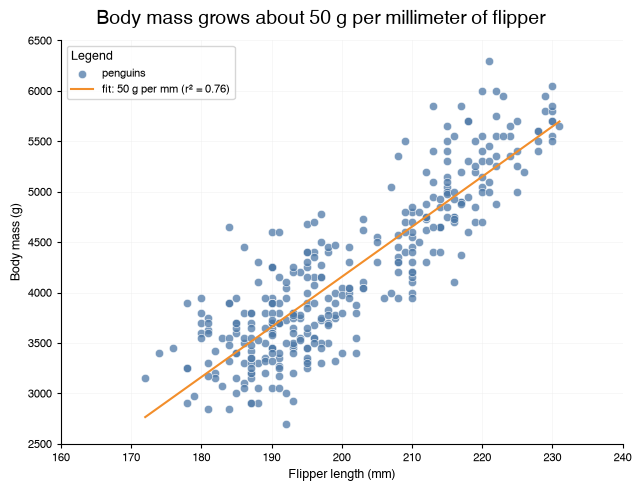

In [14]:
from datachart.charts import LineChart
from datachart.utils import Panel

ends = [stats.minimum(flipper), stats.maximum(flipper)]

Panel(
    [
        ScatterChart(data=[{"x": f, "y": m} for f, m in zip(flipper, mass)], subtitle="penguins"),
        LineChart(
            data=[{"x": x, "y": slope * x + intercept} for x in ends],
            subtitle=f"fit: {slope:.0f} g per mm (r² = {r2:.2f})",
        ),
    ],
    title="Body mass grows about 50 g per millimeter of flipper",
    xlabel="Flipper length (mm)",
    ylabel_left="Body mass (g)",
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Confidence intervals

*How sure is this mean?* A sample mean is an estimate, and a different sample would give a different one. `bootstrap_ci` puts a range on it without assuming a distribution: it resamples the values with replacement `n_resamples` times (1000 by default), computes the `statistic` (the `mean` by default) on each resample, and returns the central `level` share of the results (95% by default). Pass a `seed` so the interval is the same on every run. Only 68 Chinstrap penguins were measured against 151 Adelie, so the Chinstrap interval is wider:

In [15]:
{
    species: tuple(round(v) for v in stats.bootstrap_ci(values, seed=42))
    for species, values in mass_by_species.items()
}

{'Adelie': (3631, 3769), 'Chinstrap': (3649, 3827), 'Gentoo': (4990, 5159)}

The half-width of the interval is a ready-made error bar. A [Bar Chart](../../charts/barchart/) of the species means with `yerr` set to it, and `show_yerr` on, says at a glance that the Adelie and Chinstrap means are indistinguishable while the Gentoo mean is far off:

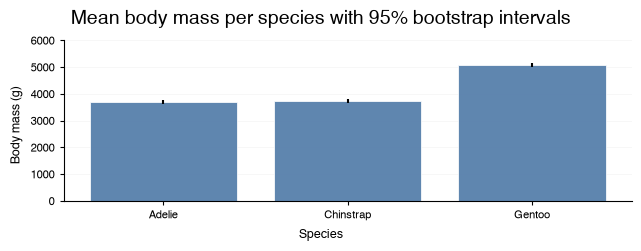

In [16]:
from datachart.charts import BarChart

bars = []
for species, values in mass_by_species.items():
    low, high = stats.bootstrap_ci(values, seed=42)
    bars.append({"label": species, "y": stats.mean(values), "yerr": (high - low) / 2})

BarChart(
    data=bars,
    title="Mean body mass per species with 95% bootstrap intervals",
    xlabel="Species",
    ylabel="Body mass (g)",
    show_yerr=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_SHORT,
).show()

Any statistic works: pass `statistic=stats.median` for a robust center, or `stats.iqr` for the uncertainty of a spread. The statistic is a function of a list, so a `lambda` fits too.

In [17]:
stats.bootstrap_ci(mass_by_species["Gentoo"], statistic=stats.median, seed=42)

(4900.0, 5200.0)

### Binning

*How many bins should a histogram have?* Too few hide the shape, too many show noise. `histogram(values, bins)` returns the `(counts, edges)` of a histogram, with one more edge than counts, and its `bins` argument accepts the rules of `numpy.histogram_bin_edges`: `"auto"` (the default), `"fd"` (Freedman–Diaconis, robust to outliers), `"sturges"` (few bins, for small normal samples), `"rice"`, or an integer or an explicit list of edges. On the pooled flipper length the Freedman–Diaconis rule picks the bins from the spread and the sample size:

In [18]:
counts, edges = stats.histogram(flipper, bins="fd")
len(counts), [round(e) for e in edges[:4]]

(9, [172, 179, 185, 192])

The [Histogram](../../charts/histogram/) front takes a fixed `num_bins`, so the rule is how to let the data choose it. The counts and edges also draw directly as a [Bar Chart](../../charts/barchart/), which is the way to plot bins that were computed elsewhere or to label them by hand:

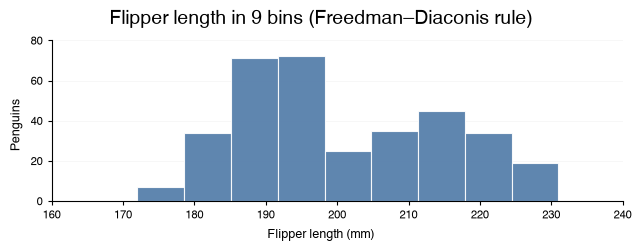

In [19]:
Histogram(
    data=[{"x": f} for f in flipper],
    # the number of bins the Freedman-Diaconis rule chose
    num_bins=len(counts),
    title=f"Flipper length in {len(counts)} bins (Freedman–Diaconis rule)",
    xlabel="Flipper length (mm)",
    ylabel="Penguins",
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Smoothing

*What is the trend under the noise?* A series measured over time jitters from one reading to the next, and the eye reads the jitter as signal. The three smoothers each return a series that lines up with the input, so they draw as extra lines over the raw one, and each answers the question differently:

- `rolling_mean(values, window)` replaces each value by the mean of the `window` values ending there. It is easy to explain and to reproduce, but the first `window - 1` outputs are `nan`, and it lags the data by half a window.
- `ewma(values, alpha)` blends each value with the previous output, `alpha * value + (1 - alpha) * previous`, so it starts at once and weights recent values most. A larger `alpha` follows the data more closely; a smaller one smooths harder.
- `loess(x, y, frac)` fits a local straight line through the nearest `frac` share of the points at every `x`, weighted so closer points count more. It follows curves, has no lag and no warm-up, and is the smoother to show when the shape of the trend is the message.

The smoothers need a time series, so this section switches to a second dataset: the global mean surface temperature anomaly of each year from 1880 to 2024, in °C relative to the 1951–1980 mean (source: NASA GISTEMP v4, rounded), in a hidden cell as `YEARS` and `ANOMALY`. The raw series is noisy enough that the year-to-year swings hide the acceleration after 1970:

In [20]:
# global mean surface temperature anomaly in °C relative to 1951-1980 (NASA GISTEMP v4, rounded)
YEARS = list(range(1880, 2025))
ANOMALY = [
    -0.17, -0.09, -0.11, -0.17, -0.28, -0.33, -0.31, -0.36, -0.17, -0.10,
    -0.35, -0.22, -0.27, -0.31, -0.30, -0.23, -0.11, -0.11, -0.27, -0.17,
    -0.08, -0.15, -0.28, -0.37, -0.47, -0.26, -0.22, -0.39, -0.43, -0.48,
    -0.43, -0.44, -0.36, -0.34, -0.15, -0.14, -0.36, -0.46, -0.30, -0.28,
    -0.27, -0.19, -0.28, -0.26, -0.27, -0.22, -0.11, -0.22, -0.20, -0.36,
    -0.16, -0.09, -0.16, -0.29, -0.12, -0.20, -0.15, -0.03, 0.00, -0.02,
    0.13, 0.19, 0.07, 0.09, 0.20, 0.09, -0.07, -0.03, -0.11, -0.11,
    -0.17, -0.07, 0.01, 0.08, -0.13, -0.14, -0.19, 0.05, 0.06, 0.03,
    -0.03, 0.06, 0.03, 0.05, -0.20, -0.11, -0.06, -0.02, -0.08, 0.05,
    0.03, -0.08, 0.01, 0.16, -0.07, -0.01, -0.10, 0.18, 0.07, 0.16,
    0.26, 0.32, 0.14, 0.31, 0.16, 0.12, 0.18, 0.32, 0.39, 0.27,
    0.45, 0.41, 0.22, 0.23, 0.32, 0.45, 0.33, 0.46, 0.61, 0.38,
    0.39, 0.54, 0.63, 0.62, 0.53, 0.68, 0.64, 0.66, 0.54, 0.66,
    0.72, 0.61, 0.65, 0.68, 0.75, 0.90, 1.02, 0.92, 0.85, 0.98,
    1.01, 0.85, 0.89, 1.17, 1.28,
]

In [21]:
smoothed = {
    "10-year rolling mean": stats.rolling_mean(ANOMALY, window=10),
    "EWMA (alpha 0.1)": stats.ewma(ANOMALY, alpha=0.1),
    "LOESS (frac 0.2)": [p["y"] for p in stats.loess(YEARS, ANOMALY, frac=0.2)],
}
{name: [round(v, 2) for v in values[-3:]] for name, values in smoothed.items()}

{'10-year rolling mean': [0.89, 0.93, 0.99],
 'EWMA (alpha 0.1)': [0.77, 0.81, 0.86],
 'LOESS (frac 0.2)': [1.04, 1.07, 1.1]}

Drawn together on one [Line Chart](../../charts/linechart/), with the raw series in the background through [emphasis](../../styling/highlighting/), the three smoothers show their characters: the rolling mean starts ten years late and runs behind every turn, the EWMA starts at once but still trails, and the LOESS curve sits in the middle of the data throughout.

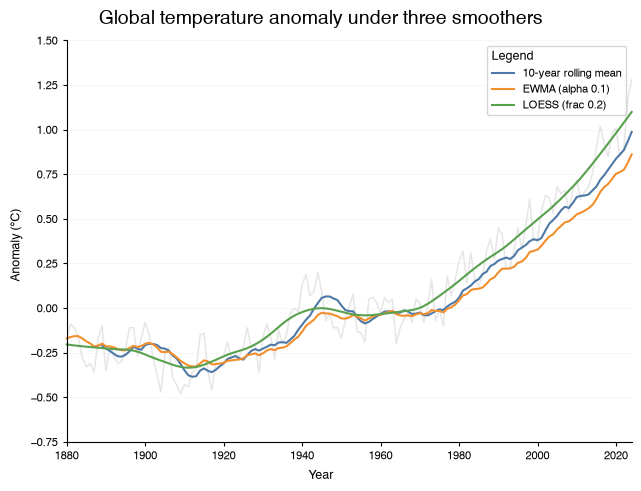

In [22]:
from datachart.constants import EMPHASIS

LineChart(
    data=[
        [{"x": y, "y": a} for y, a in zip(YEARS, ANOMALY)],
        *[[{"x": y, "y": v} for y, v in zip(YEARS, values)] for values in smoothed.values()],
    ],
    subtitle=["yearly anomaly", *smoothed],
    # the raw series is context, so it is muted and left out of the legend
    emphasis=[EMPHASIS.BACKGROUND, None, None, None],
    title="Global temperature anomaly under three smoothers",
    xlabel="Year",
    ylabel="Anomaly (°C)",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

`loess` returns `{x, y}` points sorted by `x`, so its result is already the `data` of a line chart, and its `x` may be dates or datetimes: the fit runs on the dates directly and the curve keeps them, so it lands on a date axis. `linear_fit` (its slope is then per day), `correlation`, `spearman` and `kde2d` accept dates the same way. The [Line Chart](../../charts/linechart/) guide shows a date axis in use.

### Density estimates

*What does the distribution look like, without the bins?* A histogram's shape changes with its bin edges; a kernel density estimate smooths the same values into a curve that does not. `kde1d(values)` returns the curve as `{x, y}` points ready for a [Line Chart](../../charts/linechart/); it integrates to 1, so it overlays a density [Histogram](../../charts/histogram/) of the same values on the same axis. Its `bandwidth` sets how smooth the curve is: a rule of [BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) (Scott's by default) or a number, where smaller values follow the data more closely. `gridsize` is the number of points, and `cut` how many bandwidths the curve extends past the extremes (or `xlim` fixes the range, so several curves share one grid). One curve per species, with `show_area`, is the cleanest picture of the three flipper distributions:

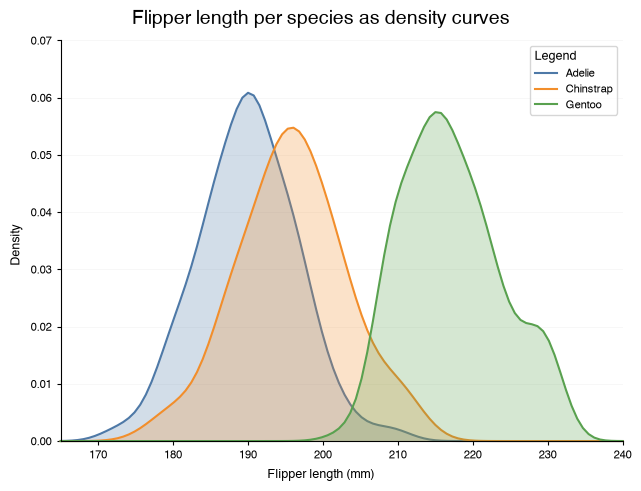

In [23]:
LineChart(
    data=[stats.kde1d(values, xlim=(165, 240)) for values in flipper_by_species.values()],
    subtitle=list(SPECIES),
    title="Flipper length per species as density curves",
    xlabel="Flipper length (mm)",
    ylabel="Density",
    show_area=True,
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

`kde2d(x, y)` does the same for pairs of values and returns the `{x, y, z}` surface a [Contour Chart](../../charts/contourchart/) draws: the density contours of a scatter, which show where the points crowd when they overplot. The `gridsize` can be one number or an `(x, y)` pair of column and row counts, and `xlim` and `ylim` fix the grid so several surfaces share it. Flipper length against body mass forms two clusters, the Gentoo one apart from the rest:

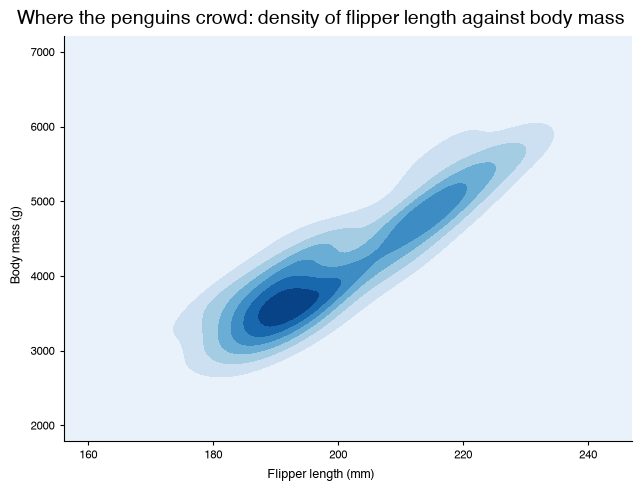

In [24]:
from datachart.charts import ContourChart

ContourChart(
    data=stats.kde2d(flipper, mass),
    title="Where the penguins crowd: density of flipper length against body mass",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    filled=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Real-World Examples

The examples below put the functions above to work, each one answering a question with a number and the chart that shows it. The first two stay with the penguins and the temperature record introduced above; the third brings its own data in a hidden cell and says where it comes from.

### Example 1: Is the Warming Speeding Up? (Linear Fits over Two Periods, a LOESS Curve, and a Note)

The question about the temperature record is not whether it rises but whether it rises faster than it used to. Two `linear_fit` calls answer it in one number each: the slope over the whole record since 1880 and the slope since 1975, both in °C per decade. A LOESS curve over the muted yearly values shows the bend the two lines summarise, and a note carries the two rates. The lines are drawn only over their own period, so the eye compares slopes, not lengths.

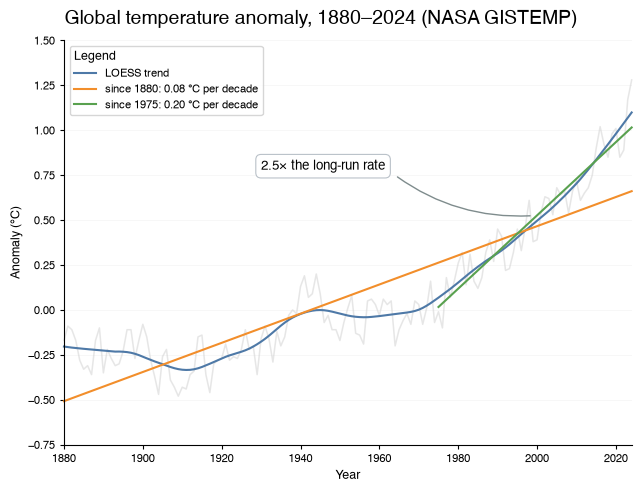

In [25]:
from datachart.constants import LEGEND_LOCATION


def trend(start):
    years = [y for y in YEARS if y >= start]
    values = ANOMALY[YEARS.index(start):]
    slope, intercept, _ = stats.linear_fit(years, values)
    line = [{"x": y, "y": slope * y + intercept} for y in (years[0], years[-1])]
    return 10 * slope, line

rate_all, line_all = trend(1880)
rate_recent, line_recent = trend(1975)

Panel(
    [
        LineChart(data=[{"x": y, "y": a} for y, a in zip(YEARS, ANOMALY)], emphasis=EMPHASIS.BACKGROUND),
        LineChart(data=stats.loess(YEARS, ANOMALY, frac=0.2), subtitle="LOESS trend"),
        LineChart(data=line_all, subtitle=f"since 1880: {rate_all:.2f} °C per decade"),
        LineChart(
            data=line_recent,
            subtitle=f"since 1975: {rate_recent:.2f} °C per decade",
            texts={
                "text": f"{rate_recent / rate_all:.1f}× the long-run rate",
                "x": 1930,
                "y": 0.8,
                "target": (2000, line_recent[0]["y"] + rate_recent * 2.5),
            },
        ),
    ],
    title="Global temperature anomaly, 1880–2024 (NASA GISTEMP)",
    xlabel="Year",
    ylabel_left="Anomaly (°C)",
    show_legend=True,
    # the lines end in the top right corner, where the legend would sit
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Are the Three Species Really Different? (Bootstrap Intervals, Density Curves, and a Grid)

A single chart of species means invites the objection that the samples are small. The answer is to show the uncertainty next to the distribution: a bar chart of the mean body mass per species with `bootstrap_ci` error bars, and the `kde1d` curves of the same values beside it. The two charts share their data, so they go in a [Grid](../grid/), and each title carries the number its chart supports.

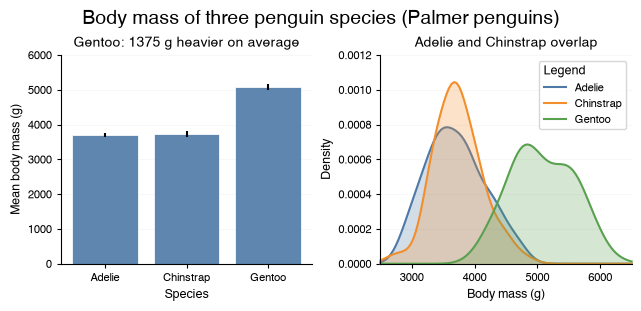

In [26]:
from datachart.utils import Grid

intervals = {species: stats.bootstrap_ci(values, seed=42) for species, values in mass_by_species.items()}
gap = stats.mean(mass_by_species["Gentoo"]) - stats.mean(mass_by_species["Adelie"])

means = BarChart(
    data=[
        {"label": species, "y": stats.mean(values), "yerr": (intervals[species][1] - intervals[species][0]) / 2}
        for species, values in mass_by_species.items()
    ],
    title=f"Gentoo: {gap:.0f} g heavier on average",
    xlabel="Species",
    ylabel="Mean body mass (g)",
    show_yerr=True,
    show_grid=SHOW_GRID.Y,
)
curves = LineChart(
    data=[stats.kde1d(values, xlim=(2_500, 6_500)) for values in mass_by_species.values()],
    subtitle=list(SPECIES),
    title="Adelie and Chinstrap overlap",
    xlabel="Body mass (g)",
    ylabel="Density",
    show_area=True,
    show_legend=True,
    show_grid=SHOW_GRID.Y,
)

Grid(
    [means, curves],
    title="Body mass of three penguin species (Palmer penguins)",
    figsize=(6.3, 3.0),
).show()

### Example 3: Did the Change Help? (Comparing Two Groups with Their Centers, Spreads, and Intervals)

An A/B test ends with two lists of numbers and the question whether they differ. `page_load` holds the illustrative page load time (in ms) of 400 visits before and 400 after a caching change, drawn from seeded log-normal generators, because load times are right-skewed: a few slow requests stretch the tail. That skew is why the mean and the median disagree, and why the comparison should be made on both, with a bootstrap interval on each. The medians go in a dumbbell (the shift), the intervals in the title, and the distributions in a pair of density curves that share one grid through `xlim`.

In [27]:
import numpy as np

rng = np.random.RandomState(42)
# illustrative page load times in ms: log-normal, the change trims the median and the tail
page_load = {
    "before": (rng.lognormal(mean=6.2, sigma=0.45, size=400)).tolist(),
    "after": (rng.lognormal(mean=6.05, sigma=0.35, size=400)).tolist(),
}

In [28]:
summary = {
    group: {
        "mean": stats.mean(values),
        "median": stats.median(values),
        "median_ci": stats.bootstrap_ci(values, statistic=stats.median, seed=42),
        "skewness": stats.skewness(values),
    }
    for group, values in page_load.items()
}
{group: {k: (round(v) if isinstance(v, float) else tuple(round(x) for x in v)) for k, v in s.items() if k != "skewness"} for group, s in summary.items()}

{'before': {'mean': 548, 'median': 506, 'median_ci': (477, 528)},
 'after': {'mean': 445, 'median': 419, 'median_ci': (403, 433)}}

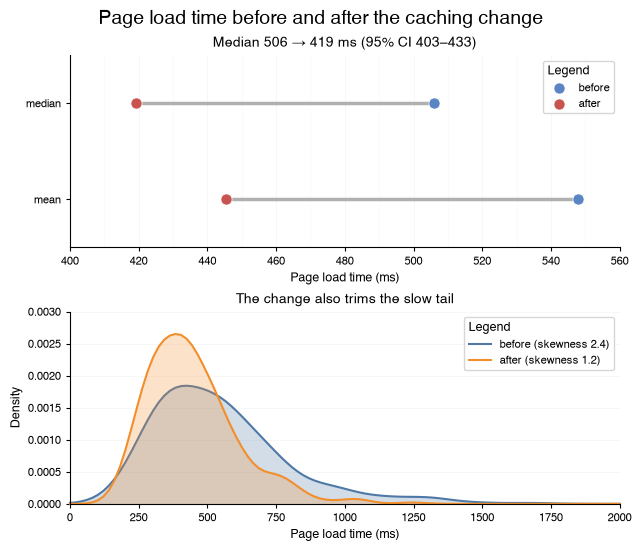

In [29]:
before, after = summary["before"], summary["after"]

shift = DumbbellChart(
    data=[
        {"label": "median", "start": before["median"], "end": after["median"]},
        {"label": "mean", "start": before["mean"], "end": after["mean"]},
    ],
    start_name="before",
    end_name="after",
    title=(
        f"Median {before['median']:.0f} → {after['median']:.0f} ms "
        f"(95% CI {after['median_ci'][0]:.0f}–{after['median_ci'][1]:.0f})"
    ),
    xlabel="Page load time (ms)",
    show_legend=True,
    show_grid=SHOW_GRID.X,
)
shapes = LineChart(
    data=[stats.kde1d(values, xlim=(0, 2_000)) for values in page_load.values()],
    subtitle=[f"{group} (skewness {s['skewness']:.1f})" for group, s in summary.items()],
    title="The change also trims the slow tail",
    xlabel="Page load time (ms)",
    ylabel="Density",
    show_area=True,
    show_legend=True,
    show_grid=SHOW_GRID.Y,
)

Grid(
    [[shift], [shapes]],
    title="Page load time before and after the caching change",
    figsize=(6.3, 5.4),
).show()